.<center> 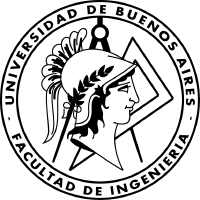



**Universidad de Buenos Aires**

**Facultad de Ingeniería**

**2do Cuatrimestre de 2025**

**Taller de Procesamiento de Señales**

---

**TP1: Regresión lineal**

**Alumno:** Lo Coco, Manuel - mlococo@fi.uba.ar - 103938 </center>

---










In [1]:
import numpy as np
import matplotlib.pyplot as plt

## (a) Simulación


Se crea un dataset de 500 muestras $X,Y$ en donde:



*   $X∼\mathcal{U}({-1,1})$
*   $Y|X=x∼\mathcal{N}(r(x),\sigma^2)$
*   $r(x)=x\mathbf{1}\{x>0\}$
*   $\sigma^2=0.04$

Y se grafican las muestras utilizando la función *scatter*.

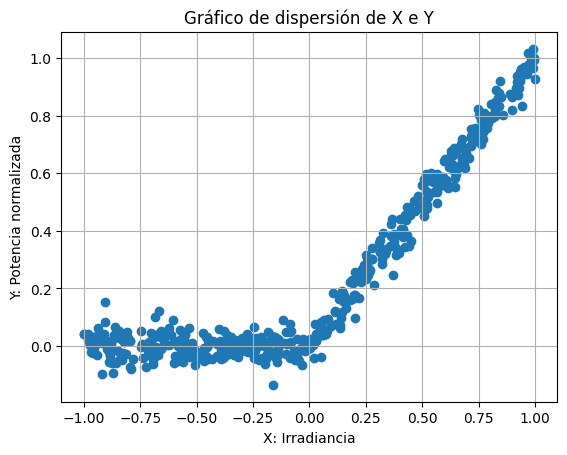

In [2]:
N=500
lim_inf=-1
lim_sup=1
sigma_cuadrado=0.04
def ReLu(x):
  return np.maximum(0,x)
X=np.random.uniform(lim_inf, lim_sup, N)
Y=np.random.normal(ReLu(X), sigma_cuadrado, 500)
plt.scatter(X,Y)
plt.xlabel("X: Irradiancia")
plt.ylabel("Y: Potencia normalizada")
plt.title("Gráfico de dispersión de X e Y")
plt.axis('on')
plt.grid()
plt.show()

## (b) Análisis Teórico

### (b.1) Cálculo de Momentos


La esperanza de un variable aleatoria uniforme de la forma $\mathcal{U}(a,b)$ es:
$$\mathbb{E}[X]=\frac{a+b}{2}$$

En este caso al ser $a=1$ y $b=-1$, se tiene que $\mathbb{E}[X]=0$.

Para calcular la $\mathbb{E}[Y]$, usamos una propiedad de la esperanza por la cual:
$$\mathbb{E}[Y]=\mathbb{E}[\mathbb{E}[Y|X]]$$
Y como la $\mathbb{E}[Y|X]=r(X)$, entonces:
$$\mathbb{E}[Y]=\mathbb{E}[r(X)]$$
La esperanza de una variable truncada puede calcularse como:
$$\mathbb{E}[g(X)|X\in A]=\frac{\mathbb{E}[g(X)\mathbf{1}\{X\in A\}]}{\mathbb{P}(X\in A)}$$
Y en este caso:
$$\mathbb{E}[X\mathbf{1}\{X>0\}]=\mathbb{P}(X>0)\cdot\mathbb{E}[X|X>0]=\frac{1}{2}\cdot\frac{1}{2}=\frac{1}{4}$$
Por lo tanto:
$$\mathbb{E}[X]=0 \ \ \ \ \ \ \mathbb{E}[Y]=\frac{1}{4}$$



La varianza de una variable aleatoria uniforme se calcula como $\text{var}(X)=\frac{(b-a)^2}{12}$, y por lo tanto, en este caso se tiene que:
$$\text{var}(X)=\frac{1}{3}$$

Para calcular $\text{var}(Y)$ se utiliza la siguiente propiedad:
$$\text{var}(Y)=\mathbb{E}[\text{var}(Y|X)]+\text{var}(\mathbb{E}[Y|X])=\mathbb{E}[\sigma^2]+\text{var}(r(X))=\sigma^2+\text{var}(r(X))$$
donde $\text{var}(r(X))$ se calcula como:
$$\text{var}(r(X))=\mathbb{E}[g(X)^2]-\mathbb{E}[g(X)]^2=\int_0^1x^2\cdot\frac{1}{2}dx-\bigg(\frac{1}{4}\bigg)^2=\frac{1}{6}-\frac{1}{16}=\frac{5}{48}$$
Finalmente se llega a que:
$$\text{var}(Y)=0.04+\frac{5}{48}\approx0.144$$

La esperanza $\mathbb{E}[XY]$ puede calcular con la siguiente propiedad:
$$\mathbb{E}[XY]=\mathbb{E}[X\mathbb{E}[Y|X]]=\int_0^1x^2\cdot\frac{1}{2}dx=\frac{1}{6}$$

Por lo tanto, todos los momentos resultan:
$$\boxed{\mathbb{E}[X]=0 \ \ \ \ \mathbb{E}[Y]=\frac{1}{4} \ \ \ \ \text{var}(X)=\frac{1}{3}\ \ \ \ \text{var}(Y)\approx 0.144 \ \ \ \ \mathbb{E}[XY]=\frac{1}{6}}$$

### (b.2) Función de regresión óptima y error bayesiano asociado


La función de regresión óptima es $\varphi(x)=\mathbb{E}[Y|X=x]=r(x)$

El error bayesiano asociado es $\mathbb{E}[\text{var}(Y|X)]=\sigma^2=0.04$

### (b.3) Mejor predictor sin observar X


El mejor predictor sin observar el valor de $X$ es $\mathbb{E}[Y]$. El error esperado que comete se puede calcular como $\mathbb{E}[(Y-\mathbb{E}[Y])^2]=\text{var}(Y)\approx 0.144$ que es mayor al error esperado con el regresor óptimo que es $\mathbb{E}[\text{var}(Y|X)]=0.04$

## (c) Regresión Lineal:

### (c.1) Implementación regresión lineal

Para la regresión lineal vamos a predecir el valor de $Y$ como:
$$\hat{Y}=w^T\cdot X+b$$
en donde:
$$\mathbf{X}=\begin{bmatrix}1&X_1\\ 1&X_2\\\vdots&\vdots\\1&X_d\end{bmatrix}\ \ \  \mathbf{y}=\begin{bmatrix}Y_1\\Y_2\\ \vdots\\ Y_d\end{bmatrix} \ \ \mathbf{W}=\begin{bmatrix}b\\ w \end{bmatrix}$$


In [3]:
class RegLineal:
    def __init__(self, ):
        self.W=None
        self.y_pred=None
        self.w_hist=[]

    # Etapa de entrenamiento con Regresión lineal
    def fit(self, X, y):
      unos = np.ones(len(X))
      X_prima= np.c_[unos, X]
      y = y.reshape(-1, 1)
      self.W=np.linalg.pinv(X_prima.T @ X_prima) @ (X_prima.T) @ y

    # Etapa de testeo
    def predict(self, X):
      self.y_pred=self.W[0]+self.W[1]* X.T
      return self.y_pred

    # Cómputo del error
    def err_predict(self,X,y):
      return np.sum((self.y_pred-y)**2)/len(y)

    # Etapa de entrenamiento con gradiente descendiente
    def fit_gradient(self, X, y, learning_rate, n_iter):
      for i in range(n_iter):
        unos = np.ones(len(X))
        X_prima= np.c_[unos, X]
        y = y.reshape(-1, 1)
        if self.W is None:
            self.W = np.ones((X_prima.shape[1], 1))
        grad_w=(2/len(y))*X_prima.T@(X_prima@self.W-y)
        self.W = self.W - learning_rate * grad_w
        self.w_hist.append(self.W)

    def params(self):
      return self.W

    def get_w_hist(self):
      return self.w_hist

### (c.2) Entrenamiento


Para el entrenamiento calcularemos:
$$\mathbf{w}=(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$
que se llega al despejar de la siguiente manera:
$$\mathbf{y}=\mathbf{X}\cdot\mathbf{W}\\
\mathbf{X}^T\mathbf{y}=\mathbf{X}^T\mathbf{X}\mathbf{W}$$

In [4]:
modelo_rl = RegLineal()
modelo_rl.fit(X, Y)
W=modelo_rl.params()
print("El valor de b es:", W[0],"\nEl valor de w es:", W[1])

El valor de b es: [0.25090079] 
El valor de w es: [0.49442511]


### (c.3) Error de Entrenamiento

El error de entrenamiento se calcula como:
$$J=\frac{1}{n}\sum_{i=1}^n(\hat{y_i}-y_i)^2$$

In [5]:
y_pred_rl=modelo_rl.predict(X)
error = modelo_rl.err_predict(X,Y)
print("El error de entrenamiento es:", error)

El error de entrenamiento es: 0.022272053552392163


### (c.4) Predicción de potencia para irradancia de 0.5

En este caso, tomando el modelo ya entreando, pedimos que calcule la potencia recibida para una irradiancia de 0.5. Para eso llamamos a la función predict y le pasamos como parámetro $X=[0.5]$ y obtenemos de potencia producida un valor aproximado de $0.5$, lo cual tiene sentido al mirar el gráfico de despersión.

In [6]:
y_pred_rl_4=modelo_rl.predict(np.array(0.5))
print("La potencia producidad para una irradianca de 0.5 es:", y_pred_rl_4)

La potencia producidad para una irradianca de 0.5 es: [0.49811334]


### (c.5) Gráficos

En el gráfico se pueden observar las curvas del regresor lineal, el regresor óptimo y la dispersión de X e Y. Puede comprobarse que el regresor lineal tiene un menor error en las zonas cercanas a la intersección con el regresor óptimo y un mayor error en las zonas donde se encuentra mas alejado del regresor óptimo.

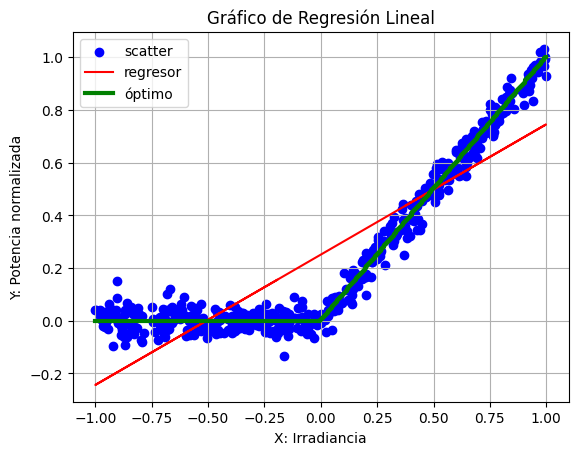

In [7]:
plt.scatter(X,Y, color="blue", label="scatter")
plt.plot(X, y_pred_rl, color="red", label="regresor")
x_aux=np.linspace(-1, 1, 500)
plt.step(x_aux, ReLu(x_aux), color="green", label="óptimo",linewidth=3)
plt.axis('on')
plt.xlabel("X: Irradiancia")
plt.ylabel("Y: Potencia normalizada")
plt.title("Gráfico de Regresión Lineal")
plt.legend()
plt.grid()
plt.show()

## (d) Gradiente Descendente

Definimos $J(\mathbf{w})$ como:
$$J(\mathbf{w})=\frac{1}{n}||\mathbf{X}\cdot\mathbf{w}-\mathbf{y}||^2$$
operando se tiene que:
$$J(\mathbf{w})=\frac{1}{n}(\mathbf{X}\cdot\mathbf{w}-\mathbf{y})^T(\mathbf{X}\cdot\mathbf{w}-\mathbf{y})=\frac{1}{n}(\mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w}-2\mathbf{X}^T\mathbf{w}^T\mathbf{y}+\mathbf{y}^T\mathbf{y})$$
Por ende,
$$ \nabla J(\mathbf{w})=\frac{1}{n}(2\mathbf{X^T}\mathbf{X}\mathbf{w}-2\mathbf{X}^T\mathbf{y})=\frac{2}{n}(\mathbf{X^T}\mathbf{X}\mathbf{w}-\mathbf{X}^T\mathbf{y})\\  \nabla J(\mathbf{w})=\frac{2}{n}\mathbf{X}^T(\mathbf{X}\mathbf{w}-\mathbf{y})$$


### (d.2.2) Entrenamiento por gradiente descendente

Se puede ver que los valores de $b$ y $w$ se asemejan bastantes los obtenidos por el regresor lineal.

In [8]:
n_iter=20
learning_rate = 0.6
modelo_gd = RegLineal()
modelo_gd.fit_gradient(X, Y, learning_rate, n_iter)
y_pred_gd=modelo_gd.predict(X)
W_gd=modelo_gd.params()
print("El valor de b es:", W_gd[0],"\nEl valor de w es:", W_gd[1])

El valor de b es: [0.2509004] 
El valor de w es: [0.49444216]


### (d.2.3) Error de entrenamiento por gradiente descendente

In [9]:
error_gd = modelo_gd.err_predict(X,Y)
error_gd2= np.sum((y_pred_gd-Y)**2)/len(Y)
print("El error de entrenamiento por gradiente descendente es:", error_gd2)

El error de entrenamiento por gradiente descendente es: 0.022272053649668885


### (d.2.4) Predicción de potencia para irradancia de 0.5 por gradiente descendente

In [10]:
y_pred_gd_4=modelo_rl.predict(np.array(0.9))
print("La potencia producidad para una irradianca de 0.5 por gradiente descendente es:",y_pred_gd_4)

La potencia producidad para una irradianca de 0.5 por gradiente descendente es: [0.69588339]


### (d.2.5) Gráfico

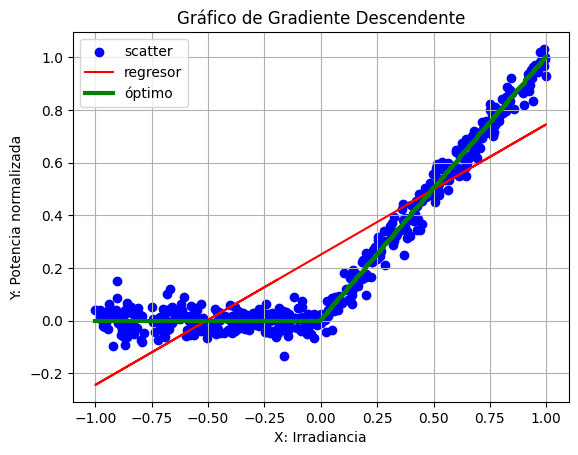

In [11]:
plt.scatter(X,Y, color="blue", label="scatter")
plt.plot(X, y_pred_gd, color="red", label="regresor")
x=np.linspace(-1, 1, 500)
plt.step(x, ReLu(x), color="green", label="óptimo",linewidth=3)
plt.axis('on')
plt.xlabel("X: Irradiancia")
plt.ylabel("Y: Potencia normalizada")
plt.legend()
plt.title("Gráfico de Gradiente Descendente")
plt.grid()
plt.show()

### (d.3) Gráfico de $w$ vs N° de iteraciones

LR=0.00 → Error=0.6805
LR=0.10 → Error=0.0224
LR=0.20 → Error=0.0223
LR=0.30 → Error=0.0223
LR=0.40 → Error=0.0223
LR=0.50 → Error=0.0223
LR=0.60 → Error=0.0223
LR=0.70 → Error=0.0223
LR=0.80 → Error=0.0223
LR=0.90 → Error=0.0223
LR=1.00 → Error=0.6420


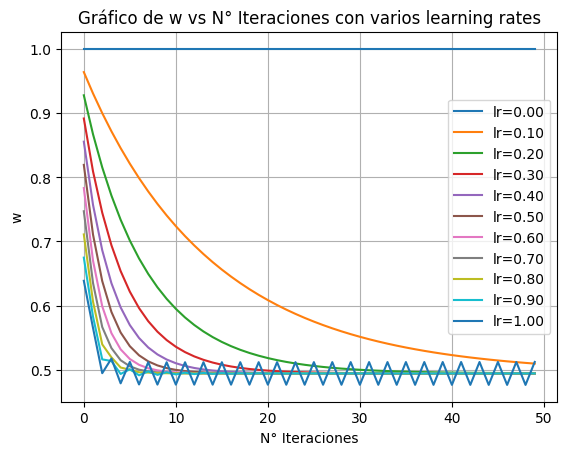

In [12]:
n_iters=50
learning_rates = np.linspace(0, 1, 11)
modelos_gd={}
for i in learning_rates:
  modelo = RegLineal()
  modelo.fit_gradient(X, Y, i, n_iters)
  modelos_gd[i]=(modelo)

for i, modelo in modelos_gd.items():
    y_pred_gd = modelo.predict(X)
    error = modelo.err_predict(X, Y)
    print(f"LR={i:.2f} → Error={error:.4f}")
    w_hists=np.array(modelo.get_w_hist())
    x_aux = np.arange(n_iters)
    plt.plot(x_aux, w_hists[:, 1], label=f"lr={i:.2f}")

plt.xlabel("N° Iteraciones")
plt.ylabel("w")
plt.title("Gráfico de w vs N° Iteraciones con varios learning rates")
plt.grid()
plt.legend()
plt.show()

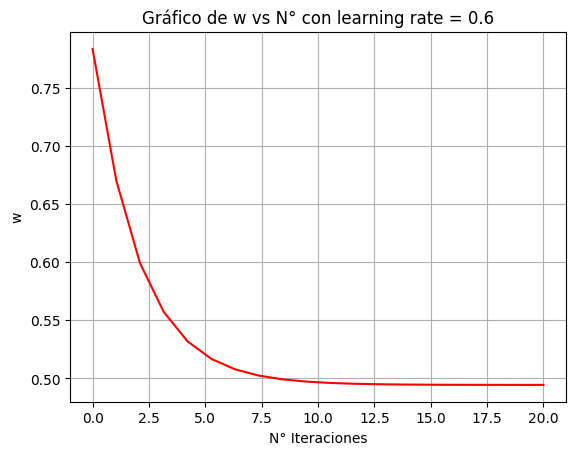

In [13]:
w_hist=np.array(modelo_gd.get_w_hist())
aux = np.linspace(0, n_iter, n_iter)
plt.plot(aux, w_hist[:,1], color="red")
plt.axis('on')
plt.xlabel("N° Iteraciones")
plt.ylabel("w")
plt.title("Gráfico de w vs N° con learning rate = 0.6")
plt.grid()
plt.show()

Se fueron probando distintos valores de $\alpha$ (Learning rate) y se comprobó que el sistema diverge para valores $\alpha>1$. Mientras más se iba aumentando el valor de $\alpha$, más rápido era la convergencia. A su vez se observa mayor oscilación alrededor del punto de equilibre al aumentar $\alpha$ con valores cercanos a $\alpha=1$. Se tomó como valor óptimo $\alpha=0.6$ ya que presenta una convergencia rápida y no presenta oscilaciones importantes.

## Conclusiones


Para conluir el trabajo, se llegó a la conclusión de que ambos métodos terminan convergiendo a la misma solución. Sin embargo, el método de gradiende descendente necesita una cierta cantidad de iteraciones para poder llegar a la misma recta que la de regresión lineal. También se destaca la necesidad de definir un valor apropiado de $\alpha$ (learning rate) para que el gradiente descendente converja lo más rápido posible. A su vez, se concluye que fue un buen primer trabajo práctico para trabajar con las herramientas que utilizaremos a lo largo de la materia.